In [1]:
pip install xgboost arch shap scikit-learn

Defaulting to user installation because normal site-packages is not writeable
     |████████████████████████████████| 925 kB 1.6 MB/s eta 0:00:01
You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use updated packages.


# Module 3: Volatility Modeling & Forecasting

This module shifts our focus to predictive modeling. We engineer technical and statistical features from our underlying asset data (`^SPX`) and train models to forecast the **21-day forward realized volatility**.

We will compare three approaches:
1. **EWMA (Baseline):** Exponentially Weighted Moving Average (a standard quant baseline).
2. **GARCH(1,1):** The classic econometric model for volatility clustering.
3. **XGBoost:** A gradient-boosted tree model that captures non-linear market regimes.

Finally, we use **SHAP (SHapley Additive exPlanations)** to deconstruct the XGBoost model and understand exactly which features drive volatility spikes.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import xgboost as xgb
from arch import arch_model
from sklearn.metrics import mean_absolute_error, mean_squared_error
import shap
import warnings

warnings.filterwarnings('ignore')

# Load the clean underlying data from Module 1
df = pd.read_csv('data/underlying_history.csv')
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date').reset_index(drop=True)

print(f"Loaded {len(df)} days of historical data.")
df.tail()

/Users/rooneysingh0027/Library/Python/3.9/lib/python/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Loaded 2893 days of historical data.


,Date,Open,High,Low,Close,Volume,log_return,hv_10,hv_21,hv_63
2888,2026-06-30,7441.270020,7508.290039,7438.040039,7499.359863,6037540000,0.007889,0.141582,0.173588,0.145514
2889,2026-07-01,7478.839844,7521.810059,7449.629883,7483.229980,5782730000,-0.002153,0.139194,0.173290,0.135819
2890,2026-07-02,7495.140137,7540.750000,7427.549805,7483.240234,5463520000,0.000001,0.122598,0.173157,0.135506
2891,2026-07-06,7506.959961,7551.310059,7500.970215,7537.430176,4971110000,0.007215,0.115600,0.173538,0.135883
2892,2026-07-07,7516.629883,7536.060059,7478.629883,7503.850098,5049590000,-0.004465,0.116425,0.173479,0.136441


In [4]:
# ------------------------------------------------------------------------
# 1. Engineer Predictive Features
# ------------------------------------------------------------------------

# Momentum: Relative Strength Index (RSI - 14 Day)
delta = df['Close'].diff()
gain = (delta.where(delta > 0, 0)).rolling(window=14).mean()
loss = (-delta.where(delta < 0, 0)).rolling(window=14).mean()
rs = gain / loss
df['RSI_14'] = 100 - (100 / (1 + rs))

# Trend: MACD
exp1 = df['Close'].ewm(span=12, adjust=False).mean()
exp2 = df['Close'].ewm(span=26, adjust=False).mean()
df['MACD'] = exp1 - exp2
df['MACD_Signal'] = df['MACD'].ewm(span=9, adjust=False).mean()

# Statistical: Rolling Skewness and Kurtosis (21-day)
df['Rolling_Skew_21'] = df['log_return'].rolling(window=21).skew()
df['Rolling_Kurt_21'] = df['log_return'].rolling(window=21).kurt()

# Price Extremes: Distance from 50-day and 200-day Moving Averages
df['SMA_50'] = df['Close'].rolling(window=50).mean()
df['SMA_200'] = df['Close'].rolling(window=200).mean()
df['Dist_SMA_50'] = (df['Close'] - df['SMA_50']) / df['SMA_50']
df['Dist_SMA_200'] = (df['Close'] - df['SMA_200']) / df['SMA_200']

# Garman-Klass Volatility (Captures intraday high/low variance)
# Formula: 0.5 * [ln(High/Low)]^2 - (2ln2 - 1) * [ln(Close/Open)]^2
df['GK_Vol'] = np.sqrt(
    0.5 * (np.log(df['High'] / df['Low']))**2 - 
    (2 * np.log(2) - 1) * (np.log(df['Close'] / df['Open']))**2
).rolling(window=21).mean() * np.sqrt(252)

df = df.dropna().reset_index(drop=True)
print("Feature Engineering Complete.")

Feature Engineering Complete.


In [5]:
# ------------------------------------------------------------------------
# 2. Define the Target Variable (Future Volatility)
# ------------------------------------------------------------------------
# We want to predict the 21-day realized volatility OVER THE NEXT 21 DAYS.
# So, we shift the hv_21 column backwards by 21 days.
FORECAST_HORIZON = 21

df['Target_Vol'] = df['hv_21'].shift(-FORECAST_HORIZON)

# Drop the last 21 days since we can't observe their future volatility yet
df_model = df.dropna(subset=['Target_Vol']).copy()

# Time-Series Split (80% Train, 20% Test)
split_idx = int(len(df_model) * 0.8)
train = df_model.iloc[:split_idx].copy()
test = df_model.iloc[split_idx:].copy()

print(f"Training set: {train['Date'].min().date()} to {train['Date'].max().date()} ({len(train)} days)")
print(f"Testing set:  {test['Date'].min().date()} to {test['Date'].max().date()} ({len(test)} days)")

Training set: 2015-10-16 to 2024-04-16 (2138 days)
Testing set:  2024-04-17 to 2026-06-04 (535 days)


In [8]:
# ------------------------------------------------------------------------
# 3. Baseline Models
# ------------------------------------------------------------------------

# Baseline 1: EWMA (Using Pandas EWM standard deviation)
# FIX: Calculate on the full df_model to keep historical memory and avoid NaNs
test['Pred_EWMA'] = df_model['log_return'].ewm(span=21).std().loc[test.index] * np.sqrt(252)

# Baseline 2: GARCH(1,1)
# GARCH requires returns scaled by 100 for numerical optimization stability
garch_returns = train['log_return'] * 100
am = arch_model(garch_returns, vol='Garch', p=1, q=1, rescale=False)
res = am.fit(disp='off')

# Rolling GARCH forecast for the test set
garch_forecasts = []
for i in range(len(test)):
    # In a real production system, you would refit GARCH daily. 
    # For speed in this backtest, we use the static parameters fitted on train data.
    forecast_var = res.forecast(horizon=FORECAST_HORIZON, start=None, align='origin').variance.iloc[-1].mean()
    # Convert daily variance back to annualized volatility decimal
    ann_vol = np.sqrt(forecast_var * 252) / 100.0
    garch_forecasts.append(ann_vol)

test['Pred_GARCH'] = garch_forecasts
print("Baseline modeling complete.")

Baseline modeling complete.


In [9]:
# ------------------------------------------------------------------------
# 4. XGBoost Volatility Predictor
# ------------------------------------------------------------------------

features = [
    'log_return', 'hv_10', 'hv_21', 'hv_63', 'RSI_14', 
    'MACD', 'MACD_Signal', 'Rolling_Skew_21', 'Rolling_Kurt_21', 
    'Dist_SMA_50', 'Dist_SMA_200', 'GK_Vol'
]

X_train, y_train = train[features], train['Target_Vol']
X_test, y_test = test[features], test['Target_Vol']

# Initialize and train XGBoost Regressor
xgb_model = xgb.XGBRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    objective='reg:squarederror'
)

xgb_model.fit(X_train, y_train)
test['Pred_XGB'] = xgb_model.predict(X_test)

# Calculate MAE for all models
mae_ewma = mean_absolute_error(test['Target_Vol'], test['Pred_EWMA'])
mae_garch = mean_absolute_error(test['Target_Vol'], test['Pred_GARCH'])
mae_xgb = mean_absolute_error(test['Target_Vol'], test['Pred_XGB'])

print(f"--- Mean Absolute Error (MAE) ---")
print(f"EWMA Baseline:   {mae_ewma:.4f}")
print(f"GARCH(1,1):      {mae_garch:.4f}")
print(f"XGBoost Model:   {mae_xgb:.4f}")

--- Mean Absolute Error (MAE) ---
EWMA Baseline:   0.0604
GARCH(1,1):      0.0558
XGBoost Model:   0.0518


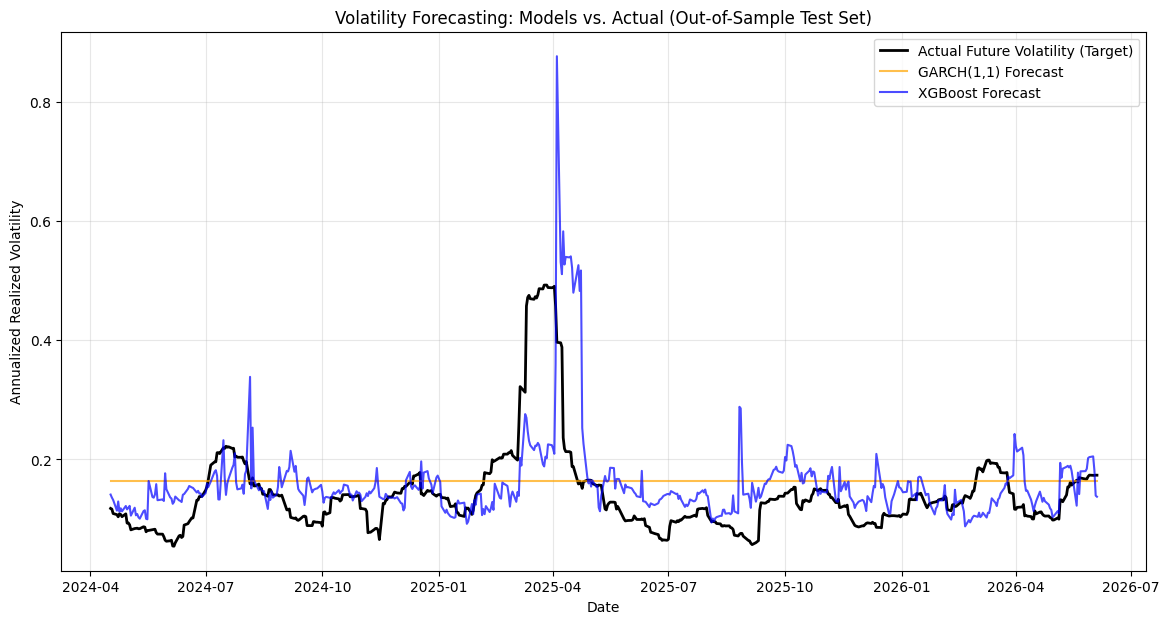

In [10]:
# ------------------------------------------------------------------------
# 5. Plotting Forecasts vs Reality
# ------------------------------------------------------------------------

plt.figure(figsize=(14, 7))
plt.plot(test['Date'], test['Target_Vol'], label='Actual Future Volatility (Target)', color='black', linewidth=2)
plt.plot(test['Date'], test['Pred_GARCH'], label='GARCH(1,1) Forecast', color='orange', alpha=0.7)
plt.plot(test['Date'], test['Pred_XGB'], label='XGBoost Forecast', color='blue', alpha=0.7)

plt.title('Volatility Forecasting: Models vs. Actual (Out-of-Sample Test Set)')
plt.xlabel('Date')
plt.ylabel('Annualized Realized Volatility')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

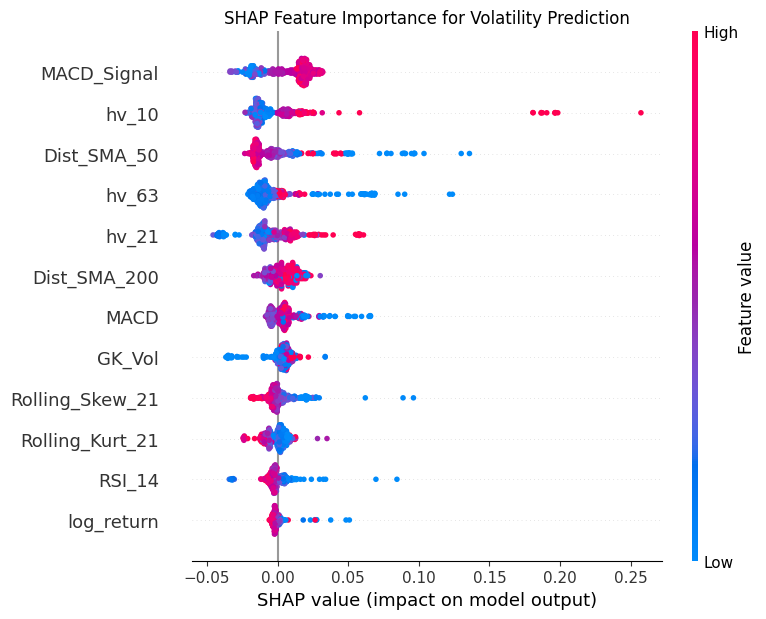

In [11]:
# ------------------------------------------------------------------------
# 6. SHAP Values (Inside the Black Box)
# ------------------------------------------------------------------------
# Let's see exactly which features XGBoost relies on to predict a volatility spike.

explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_test)

plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_test, feature_names=features, show=False)
plt.title('SHAP Feature Importance for Volatility Prediction')
plt.tight_layout()
plt.show()

In [12]:
# Save predictions for the Backtest Engine
test.to_csv('data/backtest_data.csv', index=False)
print("Data exported to data/backtest_data.csv")

Data exported to data/backtest_data.csv
